In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

Step 1 - Bringing in clean SPY data. Creating a prices dataset with all 3 ETF's. Then, calculating daily returns for SPY.

In [2]:
# Load your 3 WSJ CSV files from data folder
# Replace 'SPY.csv', 'QQQ.csv', 'IWM.csv' with your ACTUAL filenames
spy_data = pd.read_csv('/Users/Sinthu/Desktop/(Quant Trading Project)/data/spy.csv', parse_dates=['Date'], date_format='%m/%d/%y', index_col='Date')
qqq_data = pd.read_csv('/Users/Sinthu/Desktop/(Quant Trading Project)/data/qqq.csv', parse_dates=['Date'], date_format='%m/%d/%y', index_col='Date')
iwm_data = pd.read_csv('/Users/Sinthu/Desktop/(Quant Trading Project)/data/iwm.csv', parse_dates=['Date'], date_format='%m/%d/%y', index_col='Date')

#Clean up column names for each data set (they have unneccasary space at the beginning of the column
spy_data.columns = spy_data.columns.str.strip()
qqq_data.columns = qqq_data.columns.str.strip()
iwm_data.columns = iwm_data.columns.str.strip()

#Making sure dates start with oldest to newest
spy_data.sort_index(inplace=True)
qqq_data.sort_index(inplace=True)
iwm_data.sort_index(inplace=True)

# Show first few rows of each
print("SPY shape:", spy_data.shape)
print("\nSPY:")
spy_data.head()

SPY shape: (8341, 5)

SPY:


,Open,High,Low,Close,Volume
Date,,,,,
1993-01-29,43.8595,43.9688,43.7500,43.9375,1003200
1993-02-01,43.9688,44.2500,43.9688,44.2500,480500
1993-02-02,44.2188,44.3750,44.1250,44.3438,201300
1993-02-03,44.4063,44.8438,44.3750,44.8125,529400
1993-02-04,44.9688,45.0938,44.8750,45.0000,531500


In [3]:
# Extract adjusted close prices and combine
spy = pd.DataFrame({'Adj_Close': spy_data['Close']  })

print("Combined prices shape:", spy.shape)
print("\nFirst 5 rows:")
spy.head()

Combined prices shape: (8341, 1)

First 5 rows:


,Adj_Close
Date,
1993-01-29,43.9375
1993-02-01,44.2500
1993-02-02,44.3438
1993-02-03,44.8125
1993-02-04,45.0000


In [4]:
spy["log_return"] = np.log(spy["Adj_Close"] / spy["Adj_Close"].shift(1))
spy = spy.dropna(subset=["log_return"])
spy.head()

,Adj_Close,log_return
Date,,
1993-02-01,44.2500,0.007087
1993-02-02,44.3438,0.002118
1993-02-03,44.8125,0.010514
1993-02-04,45.0000,0.004175
1993-02-05,44.9688,-0.000694


Step 2 - Build a drawdown function.

- First compute cumulative returns, then compute drawdowns as distance from peak.
- Below is drawdown dataframe which can be used for any data set.

In [5]:
def compute_drawdown(return_series: pd.Series):
    """
    Given a series of periodic returns (e.g. daily log or simple returns),
    return a DataFrame with:
      - cumulative: cumulative wealth index (starting at 1.0)
      - running_max: running maximum of cumulative
      - drawdown: percentage drawdown from running max
    """
    # Convert log returns to simple if needed
    if return_series.name == "log_return":
        simple_returns = np.exp(return_series) - 1
    else:
        simple_returns = return_series

    cumulative = (1 + simple_returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = cumulative / running_max - 1.0

    out = pd.DataFrame({
        "cumulative": cumulative,
        "running_max": running_max,
        "drawdown": drawdown
    })
    return out

In [6]:
#Apply drawdowns to SPY
dd_df = compute_drawdown(spy["log_return"])
dd_df.head()

,cumulative,running_max,drawdown
Date,,,
1993-02-01,1.007112,1.007112,0.000000
1993-02-02,1.009247,1.009247,0.000000
1993-02-03,1.019915,1.019915,0.000000
1993-02-04,1.024182,1.024182,0.000000
1993-02-05,1.023472,1.024182,-0.000693


Step 3 - Plot equity curve and drawdowns

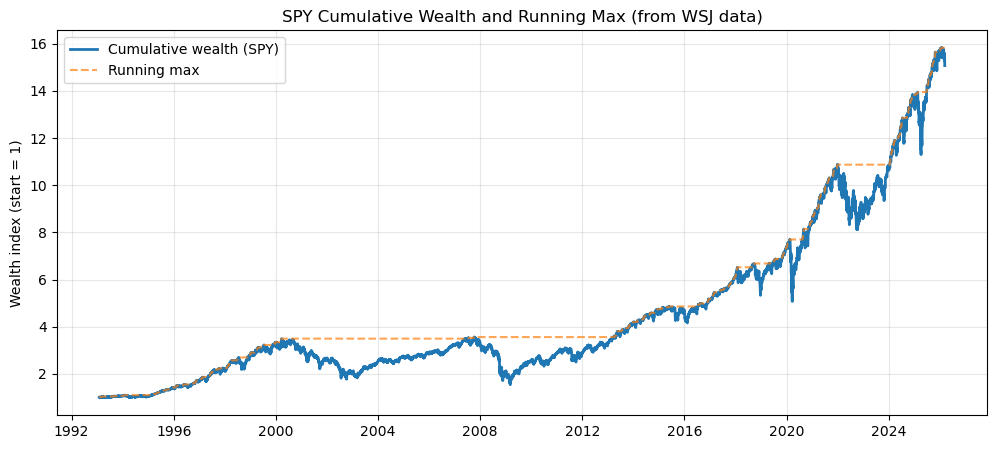

In [7]:
#Price vs cumulative wealth index
plt.figure(figsize=(12, 5))
plt.plot(dd_df.index, dd_df["cumulative"], label="Cumulative wealth (SPY)", linewidth=2)
plt.plot(dd_df.index, dd_df["running_max"], label="Running max", linestyle="--", alpha=0.7)
plt.title("SPY Cumulative Wealth and Running Max (from WSJ data)")
plt.ylabel("Wealth index (start = 1)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

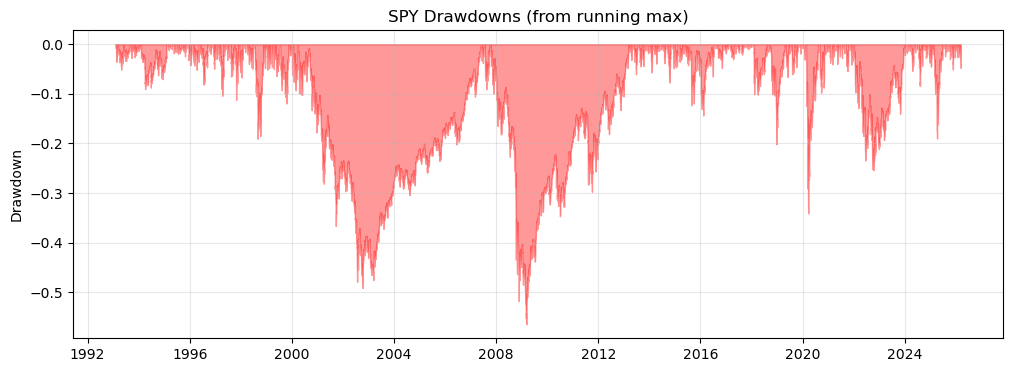

In [8]:
#Drawdown plot
plt.figure(figsize=(12, 4))
plt.fill_between(dd_df.index, dd_df["drawdown"], 0, color="red", alpha=0.4)
plt.title("SPY Drawdowns (from running max)")
plt.ylabel("Drawdown")
plt.grid(True, alpha=0.3)
plt.show()

See negative values (shown in red) showing where the strategy is below its peak.

In [9]:
max_dd = dd_df["drawdown"].min()
print(f"Maximum drawdown: {max_dd:.2%}")

Maximum drawdown: -56.47%


Show's maximum drawdown with line two giving the drawdown to 2 decimal place position. In addition, drawdown is less than or equal to 0 - as it will be less that the running max.

In [10]:
#Annualised stats
daily_mean = spy["log_return"].mean()
daily_vol = spy["log_return"].std()

annual_return = daily_mean * 252
annual_vol = daily_vol * np.sqrt(252)

print(f"Annualised return (log approx): {annual_return:.2%}")
print(f"Annualised volatility:          {annual_vol:.2%}")

Annualised return (log approx): 8.20%
Annualised volatility:          18.63%


Step 4 - Annualised volatility and Sharpe - Style metric

- We will use daily log returns to estimated annual return/ volatility

In [11]:
#Simple "Sharpe Like" ratio (risk free rate = 0)
if annual_vol != 0:
    sharpe_like = annual_return / annual_vol
else:
    sharpe_like = np.nan

print(f"Simple Sharpe-like ratio: {sharpe_like:.2f}")

Simple Sharpe-like ratio: 0.44


Sharpe ratio gives you a sense of return per unit of volatility. It's a quick performance metric to evaulate if a strategy is useful alongside:
- drawdown (risk)
- volatility (risk)
- return (reward)

High ratio is good (high return + low volatility) and Low ratio is bad (low return + high volatility).

Actual Sharpe Ratio is calculated by calculating: Sharpe = (Portfolio return - Risk free rate)/ Volatility

- Risk free rate is the rate you would make if you took now risk. So the sharpe ratio calculates the perecentage of profit return above doing nothing or wihtout taking any risk.

Step 5 - Compare rolling volatility to drawdowns 

In [12]:
spy["roll_vol_20"] = spy["log_return"].rolling(window=20).std()
spy["roll_vol_20_annual"] = spy["roll_vol_20"] * np.sqrt(252)

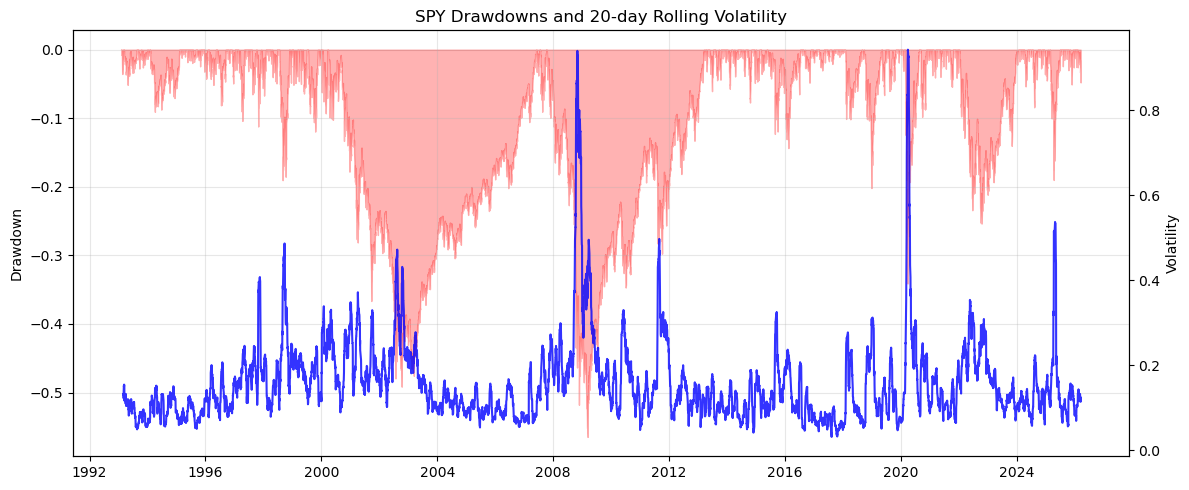

In [13]:
fig, ax1 = plt.subplots(figsize=(12, 5))

# Drawdown on left axis
ax1.fill_between(dd_df.index, dd_df["drawdown"], 0, color="red", alpha=0.3, label="Drawdown")
ax1.set_ylabel("Drawdown")
ax1.set_title("SPY Drawdowns and 20-day Rolling Volatility")
ax1.grid(True, alpha=0.3)

# Volatility on right axis
ax2 = ax1.twinx()
ax2.plot(spy.index, spy["roll_vol_20_annual"], color="blue", alpha=0.8, label="20d Ann. Vol")
ax2.set_ylabel("Volatility")

fig.tight_layout()
plt.show()

## Drawdowns & volatility – reflections (Needs to be checked before use as code input section was updated due to previous ordering mistake)

- Maximum drawdown I found for SPY (approx): -56.47 %
- How that number feels to me (e.g. "too big", "surprisingly small"):
  - "Too big" however it makes sense as the time difference bewteen the running max and the largest drawdown with be around 20 years

- What I see when comparing drawdown periods to high volatility periods:
  - Large red dip periods (dips in drawdown) concide with spikes in volatility. Prices are moving violent downward and risk is realised as actual losses Crashes like covid, 2008.
  - Volatility spikes before or during drawdowns. If volatility starts rising then drawdown worsen - can act as an early warning signal
  - Low vol means calm periods showing market is stable - prices trend smoothly upwards
  - High vol without big drawdown - happens when market is choppy but not trending down. Big up and downs cancel out.
  - Slow drawdowns with moderate vol, drawdown gradually worsens and vol not extremely high. Represents a 'grinding bear market', losses happen slowly, not in a crash.

- My understanding of annualised volatility now:
  - Calculating daily vol and multiplying by number of trading days - gives a better representation of how the vol will look if continued throughout the entire year.

- Anything confusing about the drawdown function or the plots:
  - Not confusing however drawdown doesn't seem like the best indicator with a market with a lot of data. As it's overall growing market it will show most the data to be smaller than the running max.
